
# 🎓 Assignment: Driver Fatigue Detection using CNN + LSTM

This notebook is part of an academic assignment focused on applying deep learning techniques for real-world safety-critical applications.  
The objective is to build a robust system that can identify signs of driver fatigue by analyzing sequences of video frames.  
Students are expected to understand and implement both spatial (CNN) and temporal (LSTM) feature extraction methods.

**Goals:**
- Preprocess and load sequential image data.
- Design a hybrid CNN + LSTM neural network.
- Train and evaluate the model using relevant metrics.
- Interpret the results in the context of driver safety and real-time applications.



# 🛑 Driver Fatigue Detection using CNN + LSTM


## 📌 Introduction

This notebook demonstrates a deep learning approach to detect driver fatigue using a combination of Convolutional Neural Networks (CNN) and Long Short-Term Memory (LSTM) networks.
CNNs are effective at extracting spatial features from image frames, while LSTMs capture the temporal dependencies across video sequences.


## 📁 Step 1: Import Libraries and Set Up Environment

## Import libraries

In [ ]:
!pip install mediapipe


Defaulting to user installation because normal site-packages is not writeable
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
     ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
     --------------- ------------------------ 0.5/1.3 MB 4.2 MB/s eta 0:00:01
     ---------------------------------------- 1.3/1.3 MB 4.0 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached protobuf-3.20.3-cp38-cp38-win_amd64.whl.metadata (699 bytes)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/50.8 MB ? eta -:--:--
    --------------------------------------- 0.8/50.8 MB 4.2 MB/s eta 0:00:1

In [ ]:
!pip install --upgrade --force-reinstall pandas


Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-2.0.3-cp38-cp38-win_amd64.whl.metadata (18 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl.metadata (5.6 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached pandas-2.0.3-cp38-cp38-win_amd64.whl (10.8 MB)
Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl (14.9 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 📥 Step 2: Load and Preprocess Image Data

In [ ]:
import pandas as pd
import cv2
import numpy as np
import mediapipe as mp
import os
import shutil
import matplotlib.pyplot as plt
import mediapipe as mp

mp_facemesh = mp.solutions.face_mesh
mp_drawing  = mp.solutions.drawing_utils
denormalize_coordinates = mp_drawing._normalized_to_pixel_coordinates

%matplotlib inline

In [ ]:
# Install kaggle if not already installed
!pip install -q kaggle

# Create .kaggle directory
!mkdir -p ~/.kaggle

# Create kaggle.json with your credentials
!echo '{"username":"drgnn12","key":"ff064dfdeaedc74889453b203c42db26"}' > ~/.kaggle/kaggle.json

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
The syntax of the command is incorrect.
The system cannot find the path specified.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


# Download dataset

In [ ]:
# Download the drowsiness prediction datasets
!kaggle datasets download -d rakibuleceruet/drowsiness-prediction-dataset
!kaggle datasets download -d adinishad/prediction-images

Dataset URL: https://www.kaggle.com/datasets/rakibuleceruet/drowsiness-prediction-dataset
License(s): unknown




  0%|          | 0.00/2.17G [00:00<?, ?B/s]
  0%|          | 1.00M/2.17G [00:00<25:48, 1.51MB/s]
  0%|          | 2.00M/2.17G [00:01<18:11, 2.14MB/s]
  0%|          | 3.00M/2.17G [00:01<15:30, 2.50MB/s]
  0%|          | 4.00M/2.17G [00:01<16:04, 2.41MB/s]
  0%|          | 5.00M/2.17G [00:02<15:29, 2.51MB/s]
  0%|          | 6.00M/2.17G [00:02<15:25, 2.51MB/s]
  0%|          | 7.00M/2.17G [00:03<14:48, 2.62MB/s]
  0%|          | 8.00M/2.17G [00:03<13:45, 2.82MB/s]
  0%|          | 9.00M/2.17G [00:03<12:34, 3.08MB/s]
  0%|          | 10.0M/2.17G [00:03<11:48, 3.28MB/s]
  0%|          | 11.0M/2.17G [00:04<12:05, 3.20MB/s]
  1%|          | 12.0M/2.17G [00:04<12:36, 3.07MB/s]
  1%|          | 13.0M/2.17G [00:04<11:53, 3.25MB/s]
  1%|          | 14.0M/2.17G [00:05<11:26, 3.38MB/s]
  1%|          | 15.0M/2.17G [00:05<11:05, 3.48MB/s]
  1%|          | 16.0M/2.17G [00:05<10:51, 3.56MB/s]
  1%|          | 17.0M/2.17G [00:05<10:38, 3.62MB/s]
  1%|          | 18.0M/2.17G [00:06<10:31, 3.67MB/s]
 

Dataset URL: https://www.kaggle.com/datasets/adinishad/prediction-images
License(s): unknown




  0%|          | 0.00/1.18M [00:00<?, ?B/s]
 85%|########5 | 1.00M/1.18M [00:00<00:00, 1.58MB/s]
100%|##########| 1.18M/1.18M [00:00<00:00, 1.73MB/s]


# Unzip dataset

In [ ]:
import zipfile
import os

# Define file paths and extraction destinations
zip_files = {
    "drowsiness-prediction-dataset.zip": "drowsiness_dataset",
    "prediction-images.zip": "prediction_images"
}

# Unzip each file
for zip_path, extract_to in zip_files.items():
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted '{zip_path}' to '{extract_to}/'")


Extracted 'drowsiness-prediction-dataset.zip' to 'drowsiness_dataset/'
Extracted 'prediction-images.zip' to 'prediction_images/'


In [ ]:
import os

for folder in ['drowsiness_dataset', 'prediction_images']:
    print(f"\nContents of '{folder}':")
    for root, dirs, files in os.walk(folder):
        for file in files:
            print(os.path.join(root, file))
        break  # Remove this `break` to list all subfolders too



Contents of 'drowsiness_dataset':

Contents of 'prediction_images':
prediction_images\322868_1100-1100x628.jpg
prediction_images\cell1.png
prediction_images\class5.csv
prediction_images\d41586-020-01430-5_17977552.jpg
prediction_images\daisy.jpg
prediction_images\dandelion.jpg
prediction_images\dandelion1.jpg
prediction_images\haarcascade.xml
prediction_images\haarcascade_frontalface_default.xml
prediction_images\Malaria-Parasite-Detection-Using-an-SVM-output-5-0 (2).png
prediction_images\rose.jpg
prediction_images\sunflower.jpg


In [ ]:
import os

# Create directories if they don't already exist
os.makedirs('./Fatigue Subjects', exist_ok=True)
os.makedirs('./Active Subjects', exist_ok=True)

Image preprocessing

In [ ]:
# Landmark points corresponding to left eye
all_left_eye_idxs = list(mp_facemesh.FACEMESH_LEFT_EYE)
# flatten and remove duplicates
all_left_eye_idxs = set(np.ravel(all_left_eye_idxs))

# Landmark points corresponding to right eye
all_right_eye_idxs = list(mp_facemesh.FACEMESH_RIGHT_EYE)
all_right_eye_idxs = set(np.ravel(all_right_eye_idxs))

# Combined for plotting - Landmark points for both eye
all_idxs = all_left_eye_idxs.union(all_right_eye_idxs)

# The chosen 12 points:   P1,  P2,  P3,  P4,  P5,  P6
chosen_left_eye_idxs  = [362, 385, 387, 263, 373, 380]
chosen_right_eye_idxs = [33,  160, 158, 133, 153, 144]
all_chosen_idxs = chosen_left_eye_idxs + chosen_right_eye_idxs

## 📥 Step 2: Load and Preprocess Image Data

In [ ]:
IMG_SIZE=145
i=0
def draw(
    *,n=i,
    img_dt,cat,
    img_eye_lmks=None,
    img_eye_lmks_chosen=None,
    face_landmarks=None,
    ts_thickness=1,
    ts_circle_radius=2,
    lmk_circle_radius=3,
    name="1",
):
    # For plotting Face Tessellation
    image_drawing_tool = img_dt

    # For plotting all eye landmarks
    image_eye_lmks = img_dt.copy() if img_eye_lmks is None else img_eye_lmks

    # For plotting chosen eye landmarks
    img_eye_lmks_chosen = img_dt.copy() if img_eye_lmks_chosen is None else img_eye_lmks_chosen

    # Initializing drawing utilities for plotting face mesh tessellation
    connections_drawing_spec = mp_drawing.DrawingSpec(
        thickness=ts_thickness,
        circle_radius=ts_circle_radius,
        color=(255, 255, 255)
    )


    # Draw landmarks on face using the drawing utilities.
    mp_drawing.draw_landmarks(
        image=image_drawing_tool,
        landmark_list=face_landmarks,
        connections=mp_facemesh.FACEMESH_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=connections_drawing_spec,
    )
    # Get the object which holds the x, y, and z coordinates for each landmark
    landmarks = face_landmarks.landmark

    # Iterate over all landmarks.
    # If the landmark_idx is present in either all_idxs or all_chosen_idxs,
    # get the denormalized coordinates and plot circles at those coordinates.

    for landmark_idx, landmark in enumerate(landmarks):
        if landmark_idx in all_idxs:
            pred_cord = denormalize_coordinates(landmark.x,
                                                landmark.y,
                                                imgW, imgH)
            cv2.circle(image_eye_lmks,
                       pred_cord,
                       lmk_circle_radius,
                       (255, 255, 255),
                       -1
                       )

        if landmark_idx in all_chosen_idxs:
            pred_cord = denormalize_coordinates(landmark.x,
                                                landmark.y,
                                                imgW, imgH)
            cv2.circle(img_eye_lmks_chosen,
                       pred_cord,
                       lmk_circle_radius,
                       (255, 255, 255),
                       -1
                       )

    if cat=='Fatigue Subjects':
        cv2.imwrite(str('./Fatigue Subjects/'+str(n)+'.jpg'), image_drawing_tool)
    else:
        cv2.imwrite(str('./Active Subjects/'+str(n)+'.jpg'), image_drawing_tool)

    resized_array = cv2.resize(image_drawing_tool, (IMG_SIZE, IMG_SIZE))
    return resized_array

In [ ]:
imgH, imgW, _=0,0,0
def landmarks(image,category,i):
    resized_array=[]
    IMG_SIZE = 145
    image = np.ascontiguousarray(image)
    imgH, imgW, _ = image.shape

     # Running inference using static_image_mode
    with mp_facemesh.FaceMesh(
        static_image_mode=True,         # Default=False
        max_num_faces=1,                # Default=1
        refine_landmarks=False,         # Default=False
        min_detection_confidence=0.5,   # Default=0.5
        min_tracking_confidence= 0.5,) as face_mesh:

        results = face_mesh.process(image)

        # If detections are available.
        if results.multi_face_landmarks:
            for face_id, face_landmarks in enumerate(results.multi_face_landmarks):
                resized_array= draw(img_dt=image.copy(), cat=category, n=i,face_landmarks=face_landmarks)
    return resized_array

In [ ]:
import urllib.request

# URL for OpenCV's Haar Cascade for frontal face detection
url = "https://github.com/opencv/opencv/raw/master/data/haarcascades/haarcascade_frontalface_default.xml"
filename = "haarcascade_frontalface_default.xml"

# Download only if it doesn't exist
if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print("Downloaded:", filename)
else:
    print("Already exists:", filename)


Already exists: haarcascade_frontalface_default.xml


## 📥 Step 2: Load and Preprocess Image Data

In [ ]:
def face_for_yawn(
    direc=r"C:\Users\salah\drowsiness_dataset\0 FaceImages",  # updated full path
    face_cas_path="haarcascade_frontalface_default.xml"
):
    yaw_no = []
    i = 1
    IMG_SIZE = 145
    categories = ["Fatigue Subjects", "Active Subjects"]

    if not os.path.exists(face_cas_path):
        raise FileNotFoundError(f"Haar cascade file not found at: {face_cas_path}")

    face_cascade = cv2.CascadeClassifier(face_cas_path)

    for category in categories:
        path_link = os.path.join(direc, category)
        if not os.path.exists(path_link):
            print(f"Directory not found: {path_link}")
            continue

        class_num1 = categories.index(category)
        print(f"Processing category '{category}' as class {class_num1}")

        for image_name in os.listdir(path_link):
            img_path = os.path.join(path_link, image_name)
            image_array = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image_array is None:
                print(f"Failed to read image: {img_path}")
                continue

            faces = face_cascade.detectMultiScale(image_array, scaleFactor=1.3, minNeighbors=5)

            for (x, y, w, h) in faces:
                img = image_array.copy()
                roi_color = img[y:y+h, x:x+w]

                try:
                    land_face_array = landmarks(roi_color, category, i)
                    yaw_no.append([land_face_array, class_num1])
                    i += 1
                except Exception as e:
                    print(f"Error processing landmarks for image {img_path}: {e}")

    return yaw_no

# Call the function
no_yawn = face_for_yawn()


Processing category 'Fatigue Subjects' as class 0
Processing category 'Active Subjects' as class 1


In [ ]:
import os

# Print the current working directory
print("Current working directory:", os.getcwd())

# List all files and folders in the current directory
print("\nContents of the current directory:")
for item in os.listdir():
    print(" -", item)


Current working directory: C:\Users\salah

Contents of the current directory:
 - #
 - 'D#
 - -1.14-windows.xml
 - .anaconda
 - .android
 - .bash_history
 - .bio
 - .cache
 - .cargo
 - .conda
 - .condarc
 - .continuum
 - .dgl
 - .docker
 - .dotnet
 - .gitconfig
 - .gitignore
 - .idlerc
 - .insomniac
 - .ipynb_checkpoints
 - .ipython
 - .jupyter
 - .kaggle
 - .keras
 - .Ld9VirtualBox
 - .lesshst
 - .matplotlib
 - .micromamba
 - .minikube
 - .ms-ad
 - .nbi
 - .Neo4jDesktop
 - .node_repl_history
 - .openjfx
 - .Origin
 - .packettracer
 - .QtWebEngineProcess
 - .rustup
 - .spss
 - .streamlit
 - .templateengine
 - .viminfo
 - .VirtualBox
 - .virtual_documents
 - .vscode
 - .yarnrc
 - 1th.ipynb
 - 3)_Driver_Fatigue_Detection_using_(CNN_+_LSTM)_(1) (1).ipynb
 - 3D Objects
 - Active Subjects
 - Algorithm.ipynb
 - anaconda_projects
 - Analysis.ipynb
 - ansel
 - Antimicrobial_Peptide_QSAR.ipynb
 - api_example01.png
 - AppData
 - Application Data
 - BMI.ipynb
 - Cisco Packet Tracer 8.1.1
 - Cisco 

In [ ]:
dir_path = r'./Active Subjects'
print("Number of Active images :")
print(len([entry for entry in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, entry))]))

Number of Active images :
3868


In [ ]:
dir_path = r'./Fatigue Subjects'
print("Number of Fatigue images :")
print(len([entry for entry in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, entry))]))

Number of Fatigue images :
3660


## 📥 Step 2: Load and Preprocess Image Data

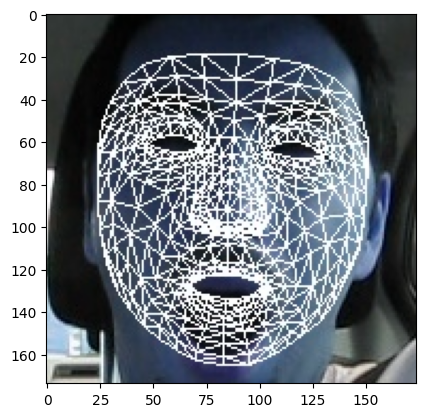

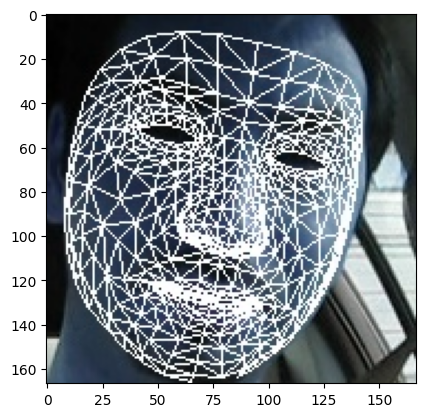

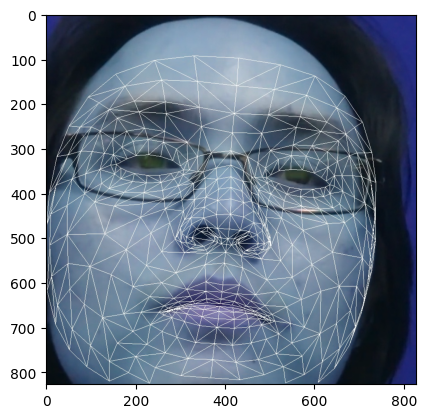

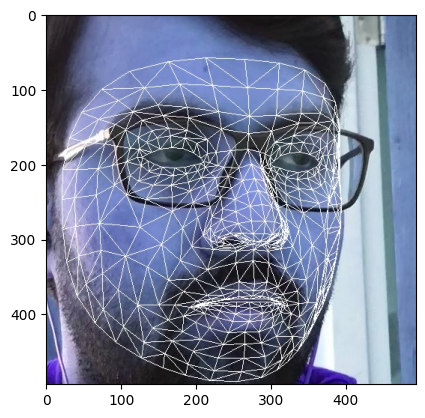

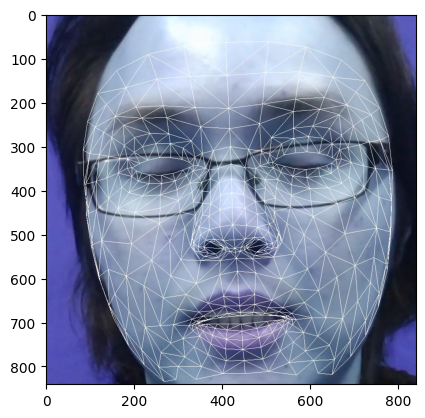

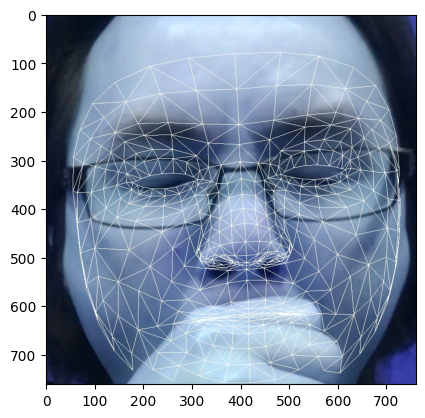

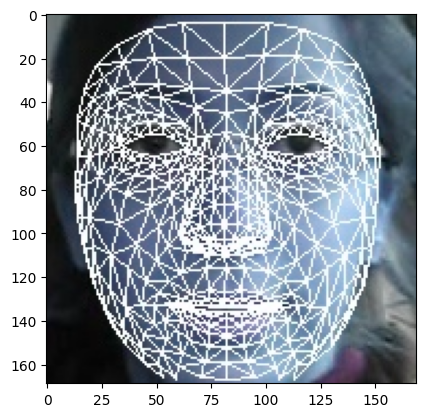

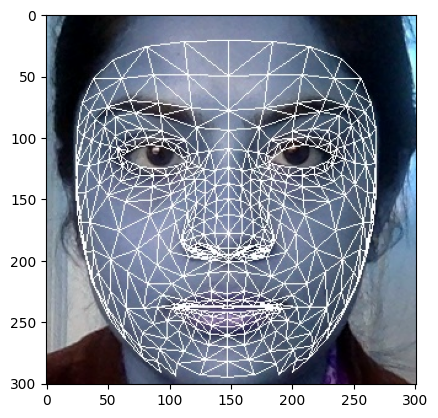

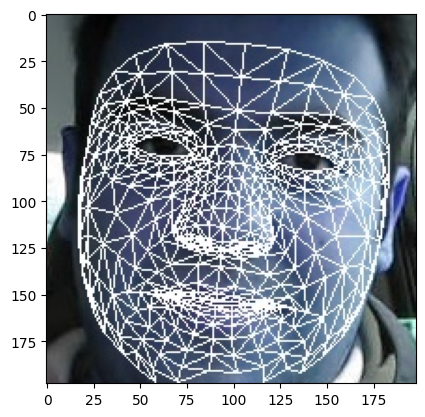

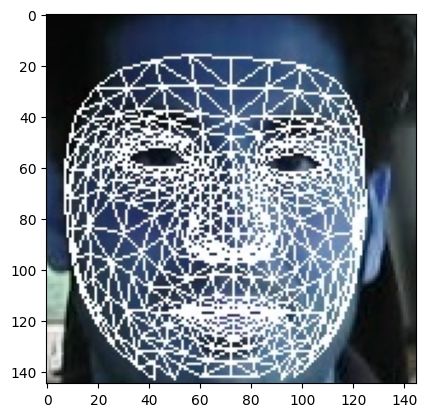

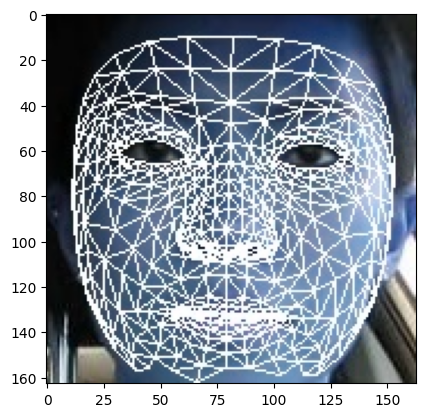

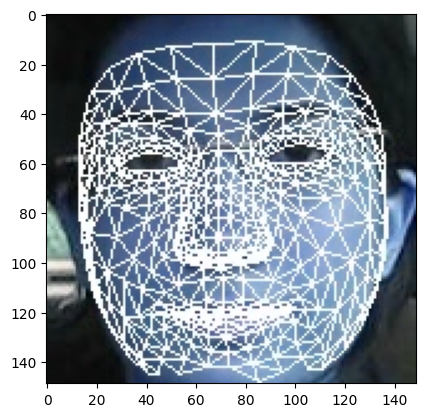

In [ ]:
categories = ["Fatigue Subjects", "Active Subjects"]
for category in categories:
  for idx, img in enumerate(os.listdir(f'./{category}')):
      if idx > 5:
        break
      img_file = cv2.imread(f'./{category}/{img}')
      plt.imshow(img_file)
      plt.show()
      plt.close()

Resizing Images

## 📥 Step 2: Load and Preprocess Image Data

In [ ]:
import os
import time
def face_for_yawn(direc="./"):
    yaw_no=[]
    i=1
    IMG_SIZE = 145
    categories = ["Fatigue Subjects", "Active Subjects"]
    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            resized_array = cv2.resize(image_array, (IMG_SIZE, IMG_SIZE))
            yaw_no.append([resized_array, class_num1])
                #print('image face number '+str(i))
                #i=i+1
    return yaw_no
yawn_no_yawn = face_for_yawn()

0
1


Seperate label and features

In [ ]:
X = []
y = []
for feature, label in yawn_no_yawn:
    X.append(feature)
    y.append(label)

Reshape the array

In [ ]:
X = np.array(X)
X = X.reshape(-1, 145, 145, 3)

Label encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_bin = LabelEncoder()
y = label_bin.fit_transform(y)
y = np.array(y)

Splitting

In [ ]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

In [ ]:
len(X_test)

1506

In [ ]:
len(X_train)

6022

In [ ]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.4.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached tensorboard-2.13.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached Markdown-3.7-py3-none-any.whl.metadata (7.0 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.0.6-py3-none-any.whl.metadata (3.7 kB)
  Using cached cachetools-5.5.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached reque

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 🧠 Step 3: Build CNN + LSTM Model

In [ ]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

Data Augmentation

In [ ]:
train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_generator = ImageDataGenerator(rescale=1/255)

train_generator = train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = test_generator.flow(np.array(X_test), y_test, shuffle=False)

## Model

In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, GlobalAveragePooling2D, Flatten
)
from tensorflow.keras.optimizers import Adam

# Define the MobileNet as the base model
base_model = MobileNet(
    weights='imagenet',  # Use pre-trained weights
    include_top=False,   # Exclude fully connected layers
    input_shape=(224, 224, 3)
)

# Freeze the base model layers to use them as feature extractors
base_model.trainable = False

# Build the custom model on top of MobileNet
model_input = Input(shape=(145, 145, 3))
x = base_model(model_input)
x = GlobalAveragePooling2D()(x)

# Fully connected layers
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

# Output layer
output = Dense(1, activation='sigmoid')(x)

# Create the final model
model = Model(inputs=model_input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
model.summary()


17225924/17225924 [==============================] - 5s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 145, 145, 3)]     0         
                                                                 
 mobilenet_1.00_224 (Functi  (None, 7, 7, 1024)        3228864   
 onal)                                                           
                                                                 
 global_average_pooling2d (  (None, 1024)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               131200    
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                               

In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, LSTM, Reshape, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

# Define the MobileNet as the base model
base_model = MobileNet(
    weights='imagenet',  # Use pre-trained weights
    include_top=False,   # Exclude fully connected layers
    input_shape=(224, 224, 3)  # Set to default MobileNet input size
)

# Freeze the base model layers to use them as feature extractors
base_model.trainable = False

# Add new layers for our specific task
model_input = Input(shape=(224, 224, 3))  # Match input shape of MobileNet
x = base_model(model_input)

# Global average pooling layer
x = GlobalAveragePooling2D()(x)  # Output: (batch_size, features)

# Add LSTM-compatible reshaping
x = Reshape((1, -1))(x)  # Reshape to (batch_size, time_steps, features)

# Add LSTM for sequence processing
x = LSTM(64, return_sequences=False)(x)

# Fully connected layers
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.25)(x)

# Output layer
output = Dense(1, activation='sigmoid')(x)

# Create the final model
model = Model(inputs=model_input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenet_1.00_224 (Functi  (None, 7, 7, 1024)        3228864   
 onal)                                                           
                                                                 
 global_average_pooling2d_1  (None, 1024)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 reshape (Reshape)           (None, 1, 1024)           0         
                                                                 
 lstm (LSTM)                 (None, 64)                278784    
                                                                 
 dense_3 (Dense)             (None, 128)               8320

## 🏋️ Step 4: Train the Model

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

# Save the trained model
model.save('CNN+LSTM Project MOdel.h5')


Epoch 1/10
189/189 [==============================] - 78s 412ms/step - loss: 0.5599 - accuracy: 0.7263 - val_loss: 0.5107 - val_accuracy: 0.7928
Epoch 2/10
189/189 [==============================] - 73s 387ms/step - loss: 0.4918 - accuracy: 0.7602 - val_loss: 0.4308 - val_accuracy: 0.7935
Epoch 3/10
189/189 [==============================] - 74s 389ms/step - loss: 0.4655 - accuracy: 0.7758 - val_loss: 0.4050 - val_accuracy: 0.8015
Epoch 4/10
189/189 [==============================] - 73s 388ms/step - loss: 0.4357 - accuracy: 0.7941 - val_loss: 0.3946 - val_accuracy: 0.8094
Epoch 5/10
189/189 [==============================] - 75s 394ms/step - loss: 0.4143 - accuracy: 0.8075 - val_loss: 0.3687 - val_accuracy: 0.8234
Epoch 6/10
189/189 [==============================] - 73s 386ms/step - loss: 0.4099 - accuracy: 0.8057 - val_loss: 0.3486 - val_accuracy: 0.8333
Epoch 7/10
189/189 [==============================] - 73s 387ms/step - loss: 0.3891 - accuracy: 0.8173 - val_loss: 0.3825 - val_ac

C:\Users\salah\AppData\Roaming\Python\Python38\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 📊 Step 5: Evaluate Model Performance

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


48/48 [==============================] - 18s 346ms/step - loss: 1.1934 - accuracy: 0.4880
Test Loss: 1.193448543548584
Test Accuracy: 0.4880478084087372


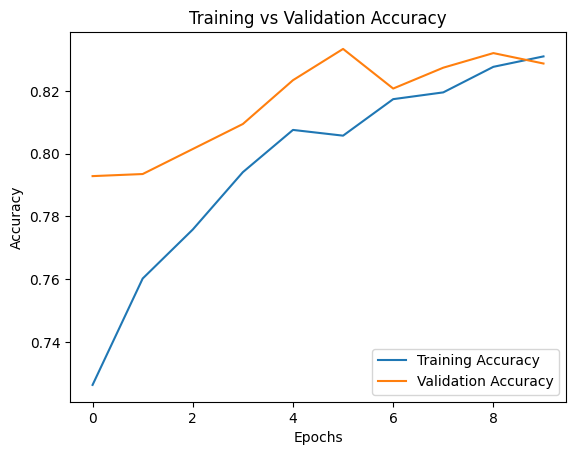

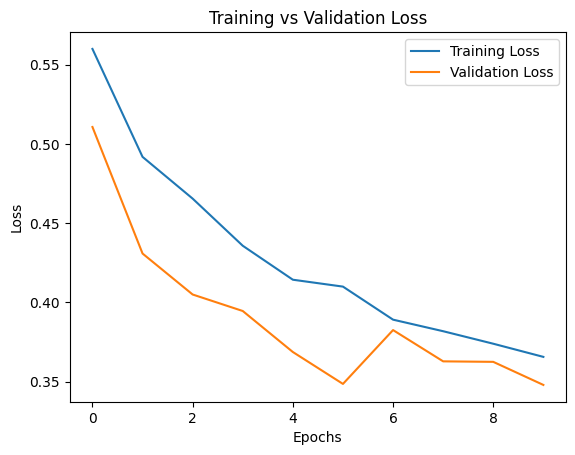

In [ ]:
# Optionally, plot training and validation accuracy/loss
import matplotlib.pyplot as plt

# Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Plotting the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

## 📊 Step 5: Evaluate Model Performance

In [ ]:
# You can evaluate or predict on a dataset.
print("Evaluate")
result = model.evaluate(test_generator)
dict(zip(model.metrics_names, result))

Evaluate
48/48 [==============================] - 15s 317ms/step - loss: 1.1934 - accuracy: 0.4880


{'loss': 1.193448543548584, 'accuracy': 0.4880478084087372}

In [ ]:
from tensorflow.keras.applications import MobileNetV2 # Importing MobileNetV2 class
from tensorflow.keras.layers import Dense, Flatten # Importing Dense, Flatten layers for layer definition
from tensorflow.keras.models import Model  # Importing Model class for model definition
import keras
from tensorflow.keras.optimizers import Adam  # Importing Adam optimizer for model compilation
# Rest of the code remains unchanged

## 🧠 Step 3: Build CNN + LSTM Model

In [ ]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 3.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 4.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/9.3 MB 3.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.3 MB 3.9 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 4.0 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 3.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.3 MB 3.9 MB/s eta 0:00:01
   ---------------------

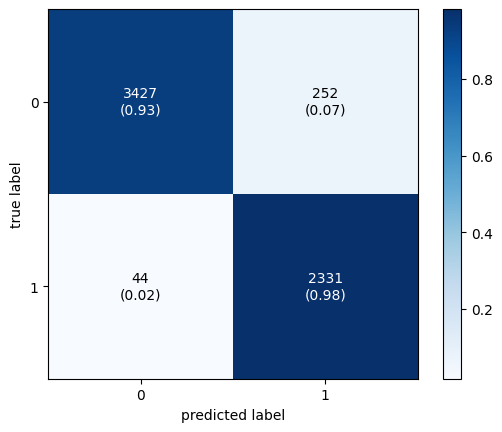

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
binary1 = np.array([[3427,252],[44,2331]])
fig, ax = plot_confusion_matrix(conf_mat=binary1,show_absolute=True,
                                show_normed=True,
                                colorbar=True)
plt.show()

In [ ]:
X = np.array([item[0] for item in yawn_no_yawn])
y = np.array([item[1] for item in yawn_no_yawn])
def create_sequences(X, y, sequence_length=10):
    X_seq, y_seq = [], []
    for i in range(0, len(X) - sequence_length + 1, sequence_length):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length - 1])  # Label of the last item in the sequence
    return np.array(X_seq), np.array(y_seq)

X_sequences, y_sequences = create_sequences(X, y)
from sklearn.model_selection import train_test_split
X_train_sequences, X_test_sequences, y_train_sequences, y_test_sequences = train_test_split(
    X_sequences, y_sequences, test_size=0.2, random_state=42)


## 🧠 Step 3: Build CNN + LSTM Model

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LSTM, TimeDistributed
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import Sequence

# Define the sequence length
sequence_length = 10

# --- Data Preparation ---
# Reshape data for TimeDistributed layers
def reshape_data(data, labels, sequence_length):
    """Reshapes data and labels to create sequences for TimeDistributed layers."""
    num_sequences = data.shape[0] // sequence_length
    data_sequences = data[:num_sequences * sequence_length].reshape(num_sequences, sequence_length, 145, 145, 3)
    # Reshape labels to match the number of sequences
    labels_sequences = labels[:num_sequences * sequence_length].reshape(num_sequences, sequence_length)
    # Take the last label of each sequence
    labels_sequences = labels_sequences[:, -1]
    return data_sequences, labels_sequences

class TimeDistributedImageDataGenerator(Sequence):
    def __init__(self, x_set, y_set, batch_size, image_data_generator):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        self.image_data_generator = image_data_generator

    def __len__(self):
        return int(np.ceil(len(self.x) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) * self.batch_size]

        # Apply augmentations to each image in the sequence
        for i in range(batch_x.shape[0]):
            for j in range(batch_x.shape[1]):
                batch_x[i, j] = self.image_data_generator.random_transform(batch_x[i, j])

        return batch_x, batch_y

# --- Data Augmentation and Generators ---
train_datagen = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_datagen = ImageDataGenerator(rescale=1/255)

# Create custom generators
train_generator = TimeDistributedImageDataGenerator(X_train_sequences, y_train_sequences, batch_size=32, image_data_generator=train_datagen)
test_generator = TimeDistributedImageDataGenerator(X_test_sequences, y_test_sequences, batch_size=32, image_data_generator=test_datagen)



# Define the model
model = Sequential()

# Add the CNN layers with Batch Normalization and Dropout
model.add(TimeDistributed(Conv2D(16, 3, activation='relu', padding='same'), input_shape=(sequence_length, 145, 145, 3)))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D()))
model.add(TimeDistributed(Dropout(0.1)))

model.add(TimeDistributed(Conv2D(32, 5, activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D()))
model.add(TimeDistributed(Dropout(0.1)))

model.add(TimeDistributed(Conv2D(64, 10, activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(MaxPooling2D()))
model.add(TimeDistributed(Dropout(0.1)))

model.add(TimeDistributed(Conv2D(128, 12, activation='relu', padding='same')))
model.add(TimeDistributed(BatchNormalization()))
model.add(TimeDistributed(Flatten()))

# Add the LSTM layer to process the sequence of CNN outputs
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.25))

# Add Dense layers for classification
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss="binary_crossentropy", metrics=["accuracy"], optimizer="adam")

# Display the model summary
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, 10, 145, 145, 16   448       
 ributed)                    )                                   
                                                                 
 time_distributed_1 (TimeDi  (None, 10, 145, 145, 16   64        
 stributed)                  )                                   
                                                                 
 time_distributed_2 (TimeDi  (None, 10, 72, 72, 16)    0         
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 10, 72, 72, 16)    0         
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, 10, 72, 72, 32)   

## Training

## 🏋️ Step 4: Train the Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Set up callbacks
callbacks = [
    ModelCheckpoint(
        filepath='best_model.keras',  # Save the best model during training
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,  # Stop training if no improvement for 10 epochs
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1  # Display progress during training
)


## Testing

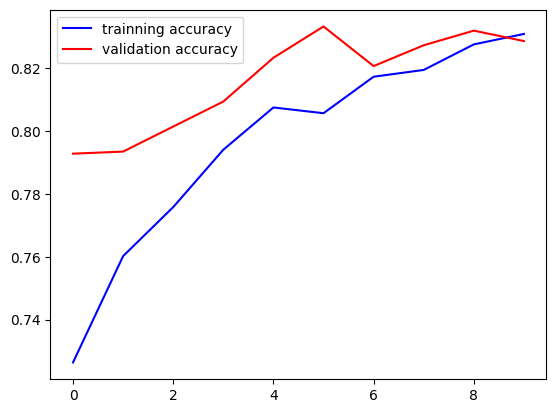

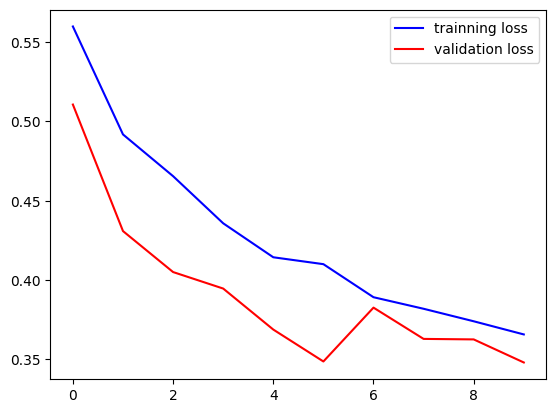

In [ ]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.show()

## 📊 Step 5: Evaluate Model Performance

In [ ]:
# You can evaluate or predict on a dataset.
print("Evaluate")
result = model.evaluate(test_generator)
dict(zip(model.metrics_names, result))

Evaluate
5/5 [==============================] - 20s 3s/step - loss: 0.6925 - accuracy: 0.5033


{'loss': 0.69251948595047, 'accuracy': 0.503311276435852}

## Saving the model

In [ ]:
model.save('my_model.h5')


Testing the model

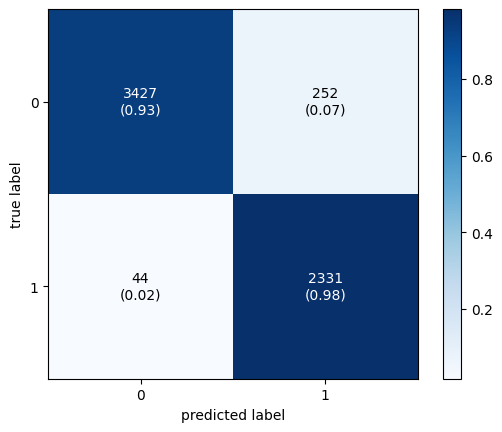

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
binary1 = np.array([[3427,252],[44,2331]])
fig, ax = plot_confusion_matrix(conf_mat=binary1,show_absolute=True,
                                show_normed=True,
                                colorbar=True)
plt.show()

Defaulting to user installation because normal site-packages is not writeable


C:\Users\salah\AppData\Roaming\Python\Python38\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


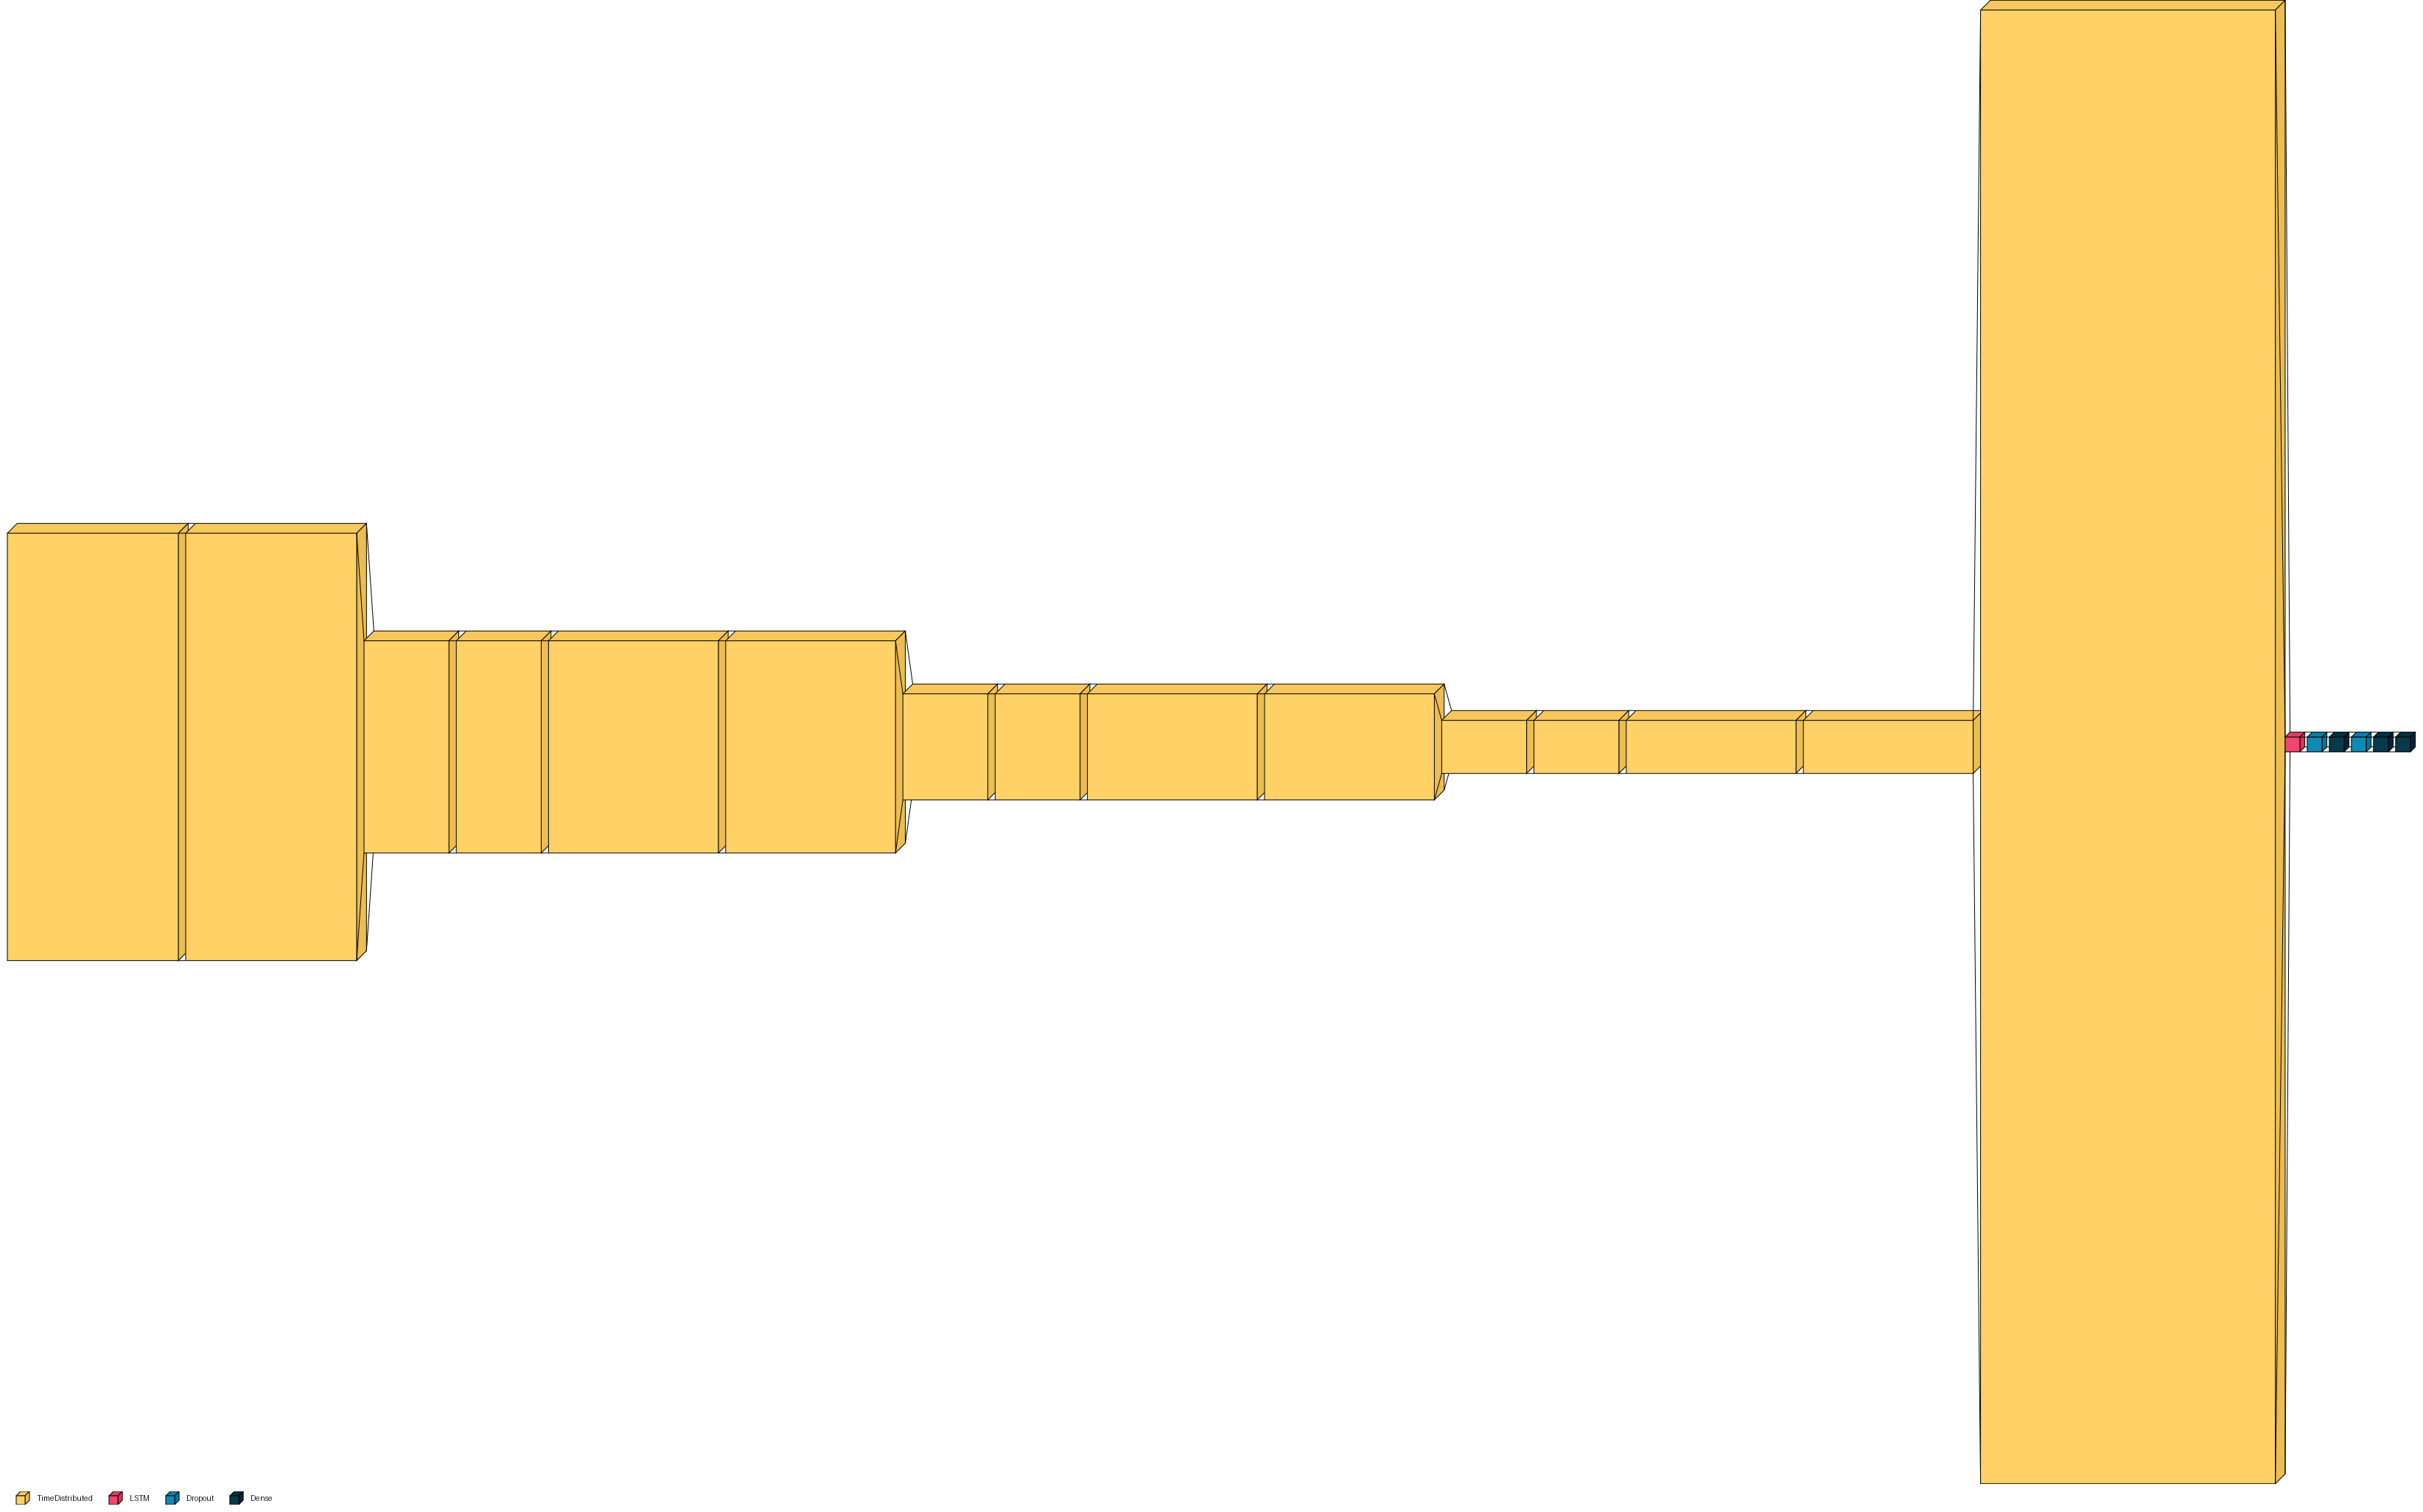

In [ ]:
!pip install visualkeras
import visualkeras

visualkeras.layered_view(model).show() # display using your system viewer
visualkeras.layered_view(model, to_file='output.png') # write to disk
visualkeras.layered_view(model, to_file='output.png').show() # write and show

visualkeras.layered_view(model,legend=True)

In [ ]:
!pip install keras_sequential_ascii
from keras_sequential_ascii import keras2ascii
keras2ascii(model)

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for keras_sequential_ascii: filename=keras_sequential_ascii-0.1.1-py3-none-any.whl size=3059 sha256=4ca361d2fc9932533e65fcc48cb210a64a4753fc1bdb77556b9e272b8cba4239
  Stored in directory: c:\users\salah\appdata\local\pip\cache\wheels\1d\3b\cf\f2f19a5b09fb1dd396eb7abb45810dc9b6ed951be2b90bea9d
Successfully built keras_sequential_ascii
           OPERATION           DATA DIMENSIONS   WEIGHTS(N)   WEIGHTS(%)

               Input   #####     10  145  145    3
     TimeDistributed   ????? -------------------       448     0.0%
                       #####     10  145  145   16
     TimeDistributed   ????? -------------------        64     0.0%
                       #####     10  145  145   16
     TimeDistributed   ????? -------------------         0     0.0%
                       #####     10  

#TEST THE MODEL ON IMAGES FROM WEB

## 📥 Step 2: Load and Preprocess Image Data

In [ ]:
import cv2
import numpy as np
from tensorflow import keras
import urllib.request
import matplotlib.pyplot as plt

In [ ]:
model = keras.models.load_model('my_model.h5')

## 📥 Step 2: Load and Preprocess Image Data

In [ ]:
IMG_SIZE = 145
image_url = 'https://thumbs.dreamstime.com/b/tired-man-car-sleepy-drowsy-driver-fatigue-driving-sleeping-vehicle-exhausted-bored-drunk-person-serious-upset-331634548.jpg?w=768'
req = urllib.request.urlopen(image_url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
image = cv2.imdecode(arr, -1)
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
image = image / 255.0
image = np.expand_dims(image, axis=0)

## 📥 Step 2: Load and Preprocess Image Data

In [ ]:
import cv2
import numpy as np
import os

# Use raw string and correct separators
base_path = r"C:\Users\salah\drowsiness_dataset\0 FaceImages\Fatigue Subjects"
sequence_images = []

for i in range(1, 11):
    image_path = os.path.join(base_path, f"{i}.jpg")
    if not os.path.exists(image_path):
        print(f"Missing: {image_path}")
        continue
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    img = cv2.resize(img, (145, 145))
    img = img / 255.0
    sequence_images.append(img)

if len(sequence_images) != 10:
    raise ValueError(f"Only {len(sequence_images)} images loaded. Need exactly 10.")

sequence = np.stack(sequence_images)
sequence = np.expand_dims(sequence, axis=0)  # Shape: (1, 10, 145, 145, 3)

prediction = model.predict(sequence)


1/1 [==============================] - 1s 1s/step


## 📥 Step 2: Load and Preprocess Image Data

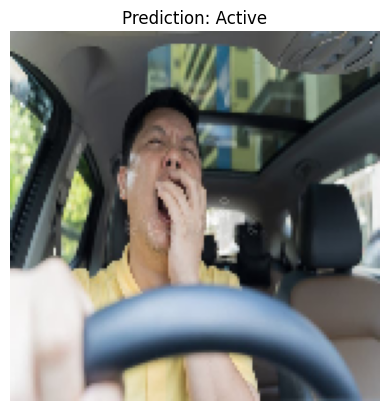

In [ ]:
plt.imshow(cv2.cvtColor(cv2.resize(cv2.imdecode(arr, -1), (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB))
plt.title(f'Prediction: {"Fatigue" if prediction[0][0] < 0.5 else "Active"}')
plt.axis('off')
plt.show()

## 📥 Step 2: Load and Preprocess Image Data

In [ ]:

IMG_SIZE = 145
image_url = 'https://photos.peopleimages.com/picture/202310/2955857-fitness-city-portrait-and-woman-exercise-determined-and-ready-for-outdoor-cardio-workout-commitment-or-sports.-sweaty-face-road-and-active-athlete-runner-or-person-for-street-training-challenge-zoom_90.jpg'
req = urllib.request.urlopen(image_url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
image = cv2.imdecode(arr, -1)
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
image = image / 255.0
image = np.expand_dims(image, axis=0)


## 📥 Step 2: Load and Preprocess Image Data

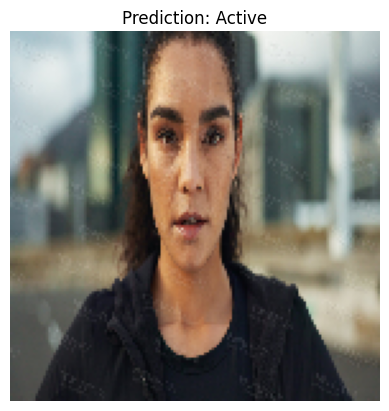

In [ ]:
plt.imshow(cv2.cvtColor(cv2.resize(cv2.imdecode(arr, -1), (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB))
plt.title(f'Prediction: {"Fatigue" if prediction[0][0] < 0.5 else "Active"}')
plt.axis('off')
plt.show()


## ✅ Conclusion

This notebook showcased how a CNN + LSTM hybrid model can be implemented to detect fatigue in drivers using sequences of image frames.
Such systems can enhance road safety by alerting users when signs of drowsiness are detected in real-time.
